In [2]:
from matplotlib import lines

from ProgettiPyCharm.main import risposta, df_citta, rinomina

pip install requests matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


### Script di ricerca (Geocoding)

In [16]:
import pandas as pd
import requests as rq


# Chiadiamo all'utente quale città vole ricercare
citta_da_cercare = input('Inserisci il nome della citta che vuoi ricercare: ')


# Cofigurazione dell'enpoint di geocoding di Open-Meteo
url_api_geocoding = "https://geocoding-api.open-meteo.com/v1/search"

parametri = {
    "name": citta_da_cercare,
    "count": "10",# Mostra fino a un massimo di 10 risultati
    "language": "it", # Nome dei paesi in italiano
}

# Ricghiesta all'api
risposta = rq.get(url_api_geocoding, params=parametri)

dati = risposta.json()

# Verifica se l'api ha trovato qualcosa
# Trasformiamo la lista dei risultati in un DataFrame usando Pandas
if "results" in dati:
    df_citta = pd.DataFrame(dati["results"])

    colonne_utili = ['name', 'country', 'admin1', 'latitude', 'longitude', 'timezone', 'temperature', 'hourly']

    colonne_presenti = [col for col in colonne_utili if col in df_citta.columns]
    df_pulito = df_citta[colonne_presenti]


    rinomina = {
        'name': 'Città',
        'country': 'Nazione',
        'admin1': 'Regione/Stato',
        'latitude': 'Latitudine',
        'longitude': 'Longitudine',
        'timezone': 'Fuso Orario',
        'temperature': 'Temperatura',
    }

    df_pulito = df_pulito.rename(columns = rinomina)

    print(f'\n Ecco i risultati trovati pe  {citta_da_cercare}\n')
    print(df_pulito.to_string())

else:
    print(f'Nessun risultato trovato per {citta_da_cercare}')


 Ecco i risultati trovati pe  Milano

       Città      Nazione            Regione/Stato  Latitudine  Longitudine         Fuso Orario
0     Milano       Italia                Lombardia    45.46427      9.18951         Europe/Rome
1     Milano  Stati Uniti                    Texas    30.71047    -96.86331     America/Chicago
2     Milano         Perù                  Huánuco    -8.74567    -76.15826        America/Lima
3     Milano       Spagna         Castiglia e León    41.09237     -6.59932       Europe/Madrid
4     Milano       Italia                   Umbria    42.78235     12.59836         Europe/Rome
5     Milano    Indonesia   Sumatra Settentrionale     2.21667     99.83333        Asia/Jakarta
6     Milano     Colombia     dipartimento di Meta     3.93333    -72.75000      America/Bogota
7     Milano   Costa Rica       Provincia di Limón    10.18982    -83.57674  America/Costa_Rica
8    Milanów      Polonia     voivodato di Lublino    51.70374     22.88830       Europe/Warsaw
9

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import requests as rq


url = 'https://api.open-meteo.com/v1/forecast'

parametri = {
    'latitude': 44.99364,
    'longitude': 11.10642,
    'hourly': 'temperature_2m',
    'timezone': 'Europe/Rome'
}

# Facciamo la chiamata HTTP Get alla'api
risposta = rq.get(url, params=parametri)
dati_json = risposta.json()

dati_meteo = {
    'Data_ora': pd.to_datetime(dati_json['hourly']['time']),
    'Temperatura': dati_json['hourly']['temperature_2m']
}

df = pd.DataFrame(dati_meteo)

print('Primi righe che mostra l\'API:')
df


Primi righe che mostra l'API:


,Data_ora,Temperatura
0,2026-05-20 00:00:00,14.4
1,2026-05-20 01:00:00,13.5
2,2026-05-20 02:00:00,12.7
3,2026-05-20 03:00:00,12.4
4,2026-05-20 04:00:00,12.4
...,...,...
163,2026-05-26 19:00:00,31.3
164,2026-05-26 20:00:00,29.9
165,2026-05-26 21:00:00,27.7
166,2026-05-26 22:00:00,25.1


# Cocolo Statiche

In [18]:
print('\n------Statistiche Veloci------')
print(f'Temperature Massima prevista: {df['Temperatura'].max()} °C')
print(f'Temperature Minima prevista:  {df['Temperatura'].min()} °C')
print(f'Temperature Media prevista:  {df['Temperatura'].mean():.2f} °C')


------Statistiche Veloci------
Temperature Massima prevista: 33.1 °C
Temperature Minima prevista:  12.2 °C
Temperature Media prevista:  22.29 °C


# Creazione del grafico

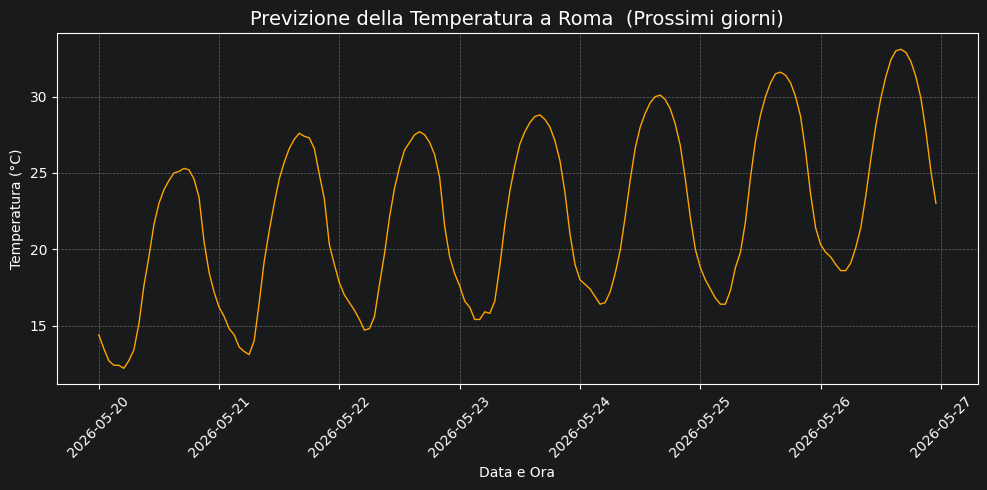

In [20]:
plt.figure(figsize = (10, 5))
plt.plot(df['Data_ora'], df['Temperatura'], color = 'orange', label = 'Temperatura', linewidth = 1)
plt.title('Previzione della Temperatura a Roma  (Prossimi giorni)', fontsize = 14)
plt.xlabel('Data e Ora')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [37]:
import tkinter as tk
from tkinter import ttk
import matplotlib
matplotlib.use('TkAgg')                    # backend Tkinter
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import (
    FigureCanvasTkAgg,
    NavigationToolbar2Tk              # toolbar zoom/pan integrata
)
import numpy as np

root = tk.Tk()
root.title("Grafico Tkinter")
root.geometry("900x600")
root.configure(bg="#1e1e2e")

# 1. Crea la Figure Matplotlib
fig = Figure(figsize=(9, 5), dpi=100,
              facecolor="#1e1e2e")
ax = fig.add_subplot(111)
ax.set_facecolor("#181825")

# 2. Disegna il grafico
x = np.linspace(0, 10, 200)
ax.plot(x, np.sin(x), color="#89b4fa", linewidth=2, label="sin(x)")
ax.plot(x, np.cos(x), color="#a6e3a1", linewidth=2, label="cos(x)")
ax.set_title("Funzioni Trigonometriche", color="#cdd6f4")
ax.set_xlabel("x", color="#a6adc8")
ax.set_ylabel("y", color="#a6adc8")
ax.tick_params(colors="#a6adc8")
ax.legend(facecolor="#313244", labelcolor="#cdd6f4")
ax.grid(alpha=0.2, color="#45475a")

# 3. Embedding in Tkinter
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.draw()
canvas.get_tk_widget().pack(fill="both", expand=True)

# 4. Toolbar opzionale (zoom, pan, salva)
toolbar = NavigationToolbar2Tk(canvas, root)
toolbar.update()

root.mainloop()

In [28]:
settori = ['Tech', 'Finance', 'Health', 'Energy', 'Retail']
quote   = [35, 20, 18, 15, 12]
colori  = ['#89b4fa', '#a6e3a1', '#f38ba8', '#fab387', '#94e2d5']

wedges, texts, autotexts = ax.pie(
    quote,
    labels=settori,
    colors=colori,
    autopct='%1.0f%%',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.6,       # crea effetto donut
                    edgecolor='#1e1e2e',
                    linewidth=2)
)

# Stile testi
for text in texts:
    text.set_color("#cdd6f4")
for autotext in autotexts:
    autotext.set_color("#1e1e2e")
    autotext.set_fontweight("bold")

ax.set_title("Quote di Mercato", color="#cdd6f4")

Text(0.5, 1.0, 'Quote di Mercato')